# 06 - Feature Hashing, and When to Use What

The last stop is the one most data scientists have already used without building: the **hashing
trick**.

You have a categorical column with two million distinct values - URLs, user ids, product SKUs,
search queries. One-hot encoding it means building a vocabulary, storing it, versioning it, keeping
training and serving in sync, and producing a two-million-wide vector. And when an unseen category
arrives in production, the pipeline breaks or silently drops it.

Feature hashing deletes all of that. Hash the category, take the remainder modulo `n_buckets`, and
that is the column index. No vocabulary. Fixed width. Unseen categories simply land somewhere
(Weinberger et al., 2009).

The cost is collisions: two categories can share a column, and the model cannot tell them apart.
Practitioners use the encoder because a library offers it, then cannot explain the degradation or
choose the bucket count. So this notebook builds it, makes the collisions visible, and plots the
tradeoff.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd

from src.config import get_settings
from src.data import generate_categorical_table
from src.evaluation.comparison import decision_guide, deep_sizeof
from src.evaluation.error_analysis import (
    feature_hashing_collision_curve,
    feature_hashing_model_curve,
)
from src.features.feature_hashing import FeatureHasher, expected_collision_rate
from src.results import load_results, results_dir, save_results
from src.visualisation import plot_feature_hashing_tradeoff, save_figure

SETTINGS = get_settings()
SEED = SETTINGS.seed

table = generate_categorical_table(
    n_rows=SETTINGS.categorical.n_rows,
    n_categories=SETTINGS.categorical.n_categories,
    n_informative=SETTINGS.categorical.n_informative,
    noise=SETTINGS.categorical.noise,
    seed=SEED,
)

print(f"{len(table):,} rows, user_id has {table['user_id'].nunique():,} distinct values "
      f"({SETTINGS.categorical.n_informative} of them actually carry signal)")
table.head()

20,000 rows, user_id has 4,914 distinct values (200 of them actually carry signal)


,user_id,city,device,y
0,user-000954,tallinn,ios,-0.326689
1,user-001278,lisbon,android,-0.064278
2,user-000207,berlin,web,-0.534956
3,user-001666,riga,web,-0.416215
4,user-004796,berlin,android,-0.429873


## The encoder, in three lines of arithmetic

`bucket = hash(token) % n_buckets`, and the value goes there. The token is `feature=value`, so
`city=berlin` and `device=berlin` stay distinct columns.

There is one refinement worth having. Give each token a `+1` or `-1` sign taken from a spare hash
bit, and colliding contributions cancel in expectation instead of piling up - the estimator stays
unbiased even though individual columns are contaminated.

In [2]:
hasher = FeatureHasher(n_buckets=SETTINGS.feature_hashing.n_buckets, seed=SEED)

row = {"user_id": "user-000042", "city": "berlin", "device": "ios"}
vector = hasher.transform_row(row)

print(hasher)
print(f"row -> vector of {len(vector)} columns, {np.count_nonzero(vector)} of them non-zero")
print()
for feature, value in row.items():
    token = f"{feature}={value}"
    print(f"  {token:<26} -> column {hasher.bucket_of(token):>4}, sign {hasher.sign_of(token):+d}")
print()
print("no vocabulary was built, stored, or consulted")

FeatureHasher(n_buckets=256, seed=20260903, alternate_sign=True)
row -> vector of 256 columns, 3 of them non-zero

  user_id=user-000042        -> column  173, sign -1
  city=berlin                -> column   95, sign +1
  device=ios                 -> column   91, sign +1

no vocabulary was built, stored, or consulted


## Collisions, made visible

Here is what "collision" actually means: two categories that share a column. The model sees their
sum and can never separate them again.

With 5,000 user ids in 256 buckets that is not an edge case - it is the normal case, and it is
fine, because most of those categories are noise anyway. The question is not *whether* to accept
collisions but *how many*, and that is what the next figure answers.

In [3]:
tokens = [f"user_id={value}" for value in sorted(table["user_id"].unique())]
small = FeatureHasher(n_buckets=256, seed=SEED)
groups = small.colliding_groups(tokens)

print(f"{len(tokens):,} categories into {small.n_buckets} buckets")
print(f"measured collision rate : {small.collision_rate(tokens):.1%}")
print(f"balls-in-bins predicts  : {expected_collision_rate(len(tokens), small.n_buckets):.1%}")
print()
print("three columns and the categories sharing them:")
for bucket, members in list(groups.items())[:3]:
    print(f"  column {bucket:>3}: {', '.join(members[:4])}{' ...' if len(members) > 4 else ''}")

saved = save_results(
    {
        "n_categories": len(tokens),
        "n_buckets": small.n_buckets,
        "measured_collision_rate": small.collision_rate(tokens),
        "expected_collision_rate": expected_collision_rate(len(tokens), small.n_buckets),
        "colliding_columns": len(groups),
        "example_collisions": {
            str(bucket): members for bucket, members in list(groups.items())[:5]
        },
    },
    "06_collisions_visible",
)
print("\nsaved ->", saved.name)

4,914 categories into 256 buckets
measured collision rate : 94.8%
balls-in-bins predicts  : 94.8%

three columns and the categories sharing them:
  column 175: user_id=user-000000, user_id=user-001140, user_id=user-001502, user_id=user-001634 ...
  column 182: user_id=user-000001, user_id=user-000044, user_id=user-001153, user_id=user-001175 ...
  column  17: user_id=user-000002, user_id=user-000058, user_id=user-000356, user_id=user-000466 ...

saved -> 06_collisions_visible.json


## The tradeoff, quantified

Two curves on one figure, which is the whole design decision:

* **collision rate** falls as buckets grow, exactly as balls-in-bins predicts - measurement and
  theory sit on top of each other, so you can compute the collision rate for your own cardinality
  without running anything;
* **model quality** (held-out R^2 of a ridge regression on the hashed features) rises with buckets,
  and then flattens.

The flat part is the useful signal. Past the point where collisions stop destroying signal, extra
buckets buy nothing except memory - so pick the knee, not the biggest number you can afford.

In [4]:
collision_curve = feature_hashing_collision_curve(
    bucket_counts=SETTINGS.feature_hashing.bucket_counts,
    n_tokens=SETTINGS.categorical.n_categories,
    seed=SEED,
)
collision_curve.round(4)

,n_buckets,n_tokens,measured_collision_rate,expected_collision_rate,bytes_per_row
0,16,5000,0.9968,0.9968,128
1,32,5000,0.9936,0.9936,256
2,64,5000,0.9872,0.9872,512
3,128,5000,0.9744,0.9744,1024
4,256,5000,0.9488,0.9488,2048
5,512,5000,0.8976,0.8976,4096
6,1024,5000,0.7968,0.7967,8192
7,4096,5000,0.4226,0.4224,32768


In [5]:
model_curve = feature_hashing_model_curve(
    table,
    bucket_counts=[count for count in SETTINGS.feature_hashing.bucket_counts if count <= 4096],
    max_rows=5_000,
    seed=SEED,
)
model_curve.round(4)

,n_buckets,alternate_sign,test_r2,collision_rate,memory_bytes
0,16,True,0.4176,0.9949,640000
1,32,True,0.4677,0.9898,1280000
2,64,True,0.4799,0.9797,2560000
3,128,True,0.5543,0.9593,5120000
4,256,True,0.5814,0.9186,10240000
5,512,True,0.5811,0.8372,20480000
6,1024,True,0.5924,0.6887,40960000
7,4096,True,0.5793,0.2998,163840000


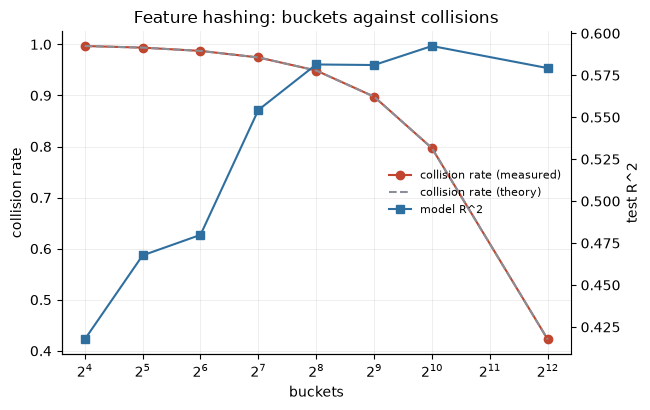

In [6]:
figure = plot_feature_hashing_tradeoff(collision_curve, model_curve)
save_figure(figure, "06_feature_hashing_tradeoff")
figure

In [7]:
# The plateau, not the maximum: the smallest width within 2% of the best score seen.
peak_r2 = model_curve["test_r2"].max()
knee = model_curve[model_curve["test_r2"] >= 0.98 * peak_r2].iloc[0]
knee_buckets = int(knee["n_buckets"])
n_categories = table["user_id"].nunique()

print(f"R^2 peaks at {peak_r2:.3f}; the curve is flat from {knee_buckets:,} buckets onward "
      f"(R^2 {knee['test_r2']:.3f} at a {knee['collision_rate']:.0%} collision rate).")
print(f"Everything past that is memory without accuracy - and at 4,096 buckets the score even "
      f"dips, because 4,096 features fitted on 3,750 training rows starts overfitting.")
print()
print(f"So: {n_categories:,} categories, and {knee_buckets:,} columns is enough. "
      f"You did not need a vocabulary to find that out.")

saved = save_results(
    {
        "collision_curve": collision_curve,
        "model_curve": model_curve,
        "peak_test_r2": float(peak_r2),
        "knee_bucket_count": knee_buckets,
        "knee_test_r2": float(knee["test_r2"]),
        "knee_collision_rate": float(knee["collision_rate"]),
        "n_categories": int(n_categories),
        "note": (
            "Measured collision rates match the balls-in-bins prediction, so the bucket count "
            "can be chosen from the formula for any cardinality without running an experiment. "
            "The argmax of the R^2 curve is noise on a plateau; the knee is the real choice."
        ),
    },
    "06_feature_hashing_tradeoff",
)
print("saved ->", saved.name)

R^2 peaks at 0.592; the curve is flat from 256 buckets onward (R^2 0.581 at a 92% collision rate).
Everything past that is memory without accuracy - and at 4,096 buckets the score even dips, because 4,096 features fitted on 3,750 training rows starts overfitting.

So: 4,914 categories, and 256 columns is enough. You did not need a vocabulary to find that out.
saved -> 06_feature_hashing_tradeoff.json


### What it actually saves

Be careful with the memory claim, because the honest version is more interesting than the
exaggerated one. Nobody stores a dense one-hot matrix; they store a sparse one. So the saving is
not mostly bytes of matrix - it is these two things:

* **the vocabulary disappears.** One-hot needs a category-to-column dictionary, built at training
  time, stored, versioned, shipped to serving, and consulted for every row. Feature hashing needs
  a modulus.
* **the width stops depending on the data.** Whatever the cardinality - today's, or next month's
  after a marketing campaign - the vector is `n_buckets` wide, and a category nobody has ever seen
  lands somewhere harmless instead of breaking the pipeline.

The table below measures the vocabulary a one-hot encoder would have to carry, and projects it to
the cardinality where people actually reach for this trick.

In [8]:
vocabulary_bytes = deep_sizeof(tokens)
bytes_per_category = vocabulary_bytes / len(tokens)

vocabulary_cost = pd.DataFrame(
    [
        {
            "n_categories": cardinality,
            "one_hot_vocabulary_mb": cardinality * bytes_per_category / 1e6,
            "one_hot_columns": cardinality,
            "feature_hashing_vocabulary_mb": 0.0,
            "feature_hashing_columns": knee_buckets,
            "measured": cardinality == len(tokens),
        }
        for cardinality in (len(tokens), 100_000, 2_000_000)
    ]
)

print(f"measured vocabulary cost: {vocabulary_bytes / 1e6:.2f} MB for {len(tokens):,} categories "
      f"({bytes_per_category:.0f} bytes each)")

saved = save_results(
    {
        "vocabulary_cost": vocabulary_cost,
        "measured_vocabulary_bytes": vocabulary_bytes,
        "bytes_per_category": bytes_per_category,
        "honest_claim": (
            "The saving is not mostly matrix bytes - a real one-hot pipeline is sparse. It is "
            "that the vocabulary disappears entirely and the width stops depending on the data."
        ),
    },
    "06_vocabulary_cost",
)
print("saved ->", saved.name)
vocabulary_cost.round(2)

measured vocabulary cost: 0.43 MB for 4,914 categories (87 bytes each)
saved -> 06_vocabulary_cost.json


,n_categories,one_hot_vocabulary_mb,one_hot_columns,feature_hashing_vocabulary_mb,feature_hashing_columns,measured
0,4914,0.43,4914,0.0,256,True
1,100000,8.67,100000,0.0,256,False
2,2000000,173.43,2000000,0.0,256,False


## Does the signed trick earn its keep?

Same sweep with `alternate_sign=False`, so colliding categories add instead of cancelling. The
signed version should hold up better where collisions are heaviest - at small bucket counts - and
the two should converge once collisions become rare.

In [9]:
unsigned_curve = feature_hashing_model_curve(
    table,
    bucket_counts=[count for count in SETTINGS.feature_hashing.bucket_counts if count <= 4096],
    max_rows=5_000,
    alternate_sign=False,
    seed=SEED,
)

signs = np.array([hasher.sign_of(token) for token in tokens])
comparison = (
    model_curve[["n_buckets", "test_r2"]]
    .rename(columns={"test_r2": "signed_r2"})
    .merge(
        unsigned_curve[["n_buckets", "test_r2"]].rename(columns={"test_r2": "unsigned_r2"}),
        on="n_buckets",
    )
    .assign(difference=lambda frame: frame["signed_r2"] - frame["unsigned_r2"])
)

print(f"mean of the +1/-1 signs over {len(signs):,} categories: {signs.mean():+.4f} "
      f"(sampling error is {1 / np.sqrt(len(signs)):.4f})")

saved = save_results(
    {
        "signed_vs_unsigned": comparison,
        "mean_sign": float(signs.mean()),
        "sign_sampling_error": float(1 / np.sqrt(len(signs))),
    },
    "06_signed_hashing",
)
print("saved ->", saved.name)
comparison.round(4)

mean of the +1/-1 signs over 4,914 categories: +0.0094 (sampling error is 0.0143)
saved -> 06_signed_hashing.json


,n_buckets,signed_r2,unsigned_r2,difference
0,16,0.4176,0.3281,0.0895
1,32,0.4677,0.4741,-0.0065
2,64,0.4799,0.5124,-0.0325
3,128,0.5543,0.5843,-0.0300
4,256,0.5814,0.5934,-0.0120
5,512,0.5811,0.5817,-0.0007
6,1024,0.5924,0.5597,0.0327
7,4096,0.5793,0.5886,-0.0094


Read that difference column carefully. Signing clearly helps where collisions are near-total (at 16
buckets, +0.09 R^2 - the regime where cancellation is the only thing keeping distinct categories
separable). Everywhere else the two are within a few hundredths of each other, which is noise on a
single train/test split, not evidence either way.

That is the honest finding: the signed trick is cheap insurance that matters most exactly when you
have under-provisioned the buckets, and is close to irrelevant once you have enough of them.

## The decision guide

Every structure in this project, and the one question it answers. The rule underneath all of them
is the same: **if the exact answer fits in memory, take the exact answer.** These structures exist
for when it does not - and each one gives up exactly one thing in exchange.

In [10]:
guide = decision_guide()
saved = save_results({"decision_guide": guide}, "06_decision_guide")
print("saved ->", saved.name)
guide

saved -> 06_decision_guide.json


,question,structure,memory,error,gives up
0,Is this item in my set? (and it fits in memory),set / dict,"O(n), ~100 bytes per item",none,"nothing, until it does not fit"
1,"Have I seen this item before, at scale?",Bloom filter,~9.6 bits per item at 1%,"false positives only, tunable",certainty on 'yes'; never on 'no'
2,"Have I seen it, and can I forget items?",Counting Bloom filter,8x a Bloom filter,false positives only,"memory, in exchange for deletion"
3,How many distinct items are there?,HyperLogLog,1.5 KB at 2.3% error,~1.04/sqrt(m) relative,the items themselves; only the count survives
4,How often did each item appear?,Count-Min Sketch,"d x w counters, fixed",overestimates by <= eps*N,accuracy on rare items; heavy hitters stay rel...
5,Which documents are near-duplicates?,MinHash + LSH,128 numbers per document,misses some pairs near the threshold,"exhaustive comparison, and the quadratic cost ..."
6,How do I encode a million categories?,Feature hashing,"n_buckets per row, fixed",collisions blur categories,interpretability of a single column


## Everything measured, in one place

The numbers below were produced by the notebooks in this repository, not quoted from papers. They
are collected here - and in `outputs/results/06_project_summary.json` - so the article, the README
and any later analysis all cite the same run.

In [11]:
summary_rows = []
sources = {
    "01_hash_quality": "hash diagnostics",
    "02_probe_cost": "hash table",
    "03_bloom_guarantee": "bloom filter",
    "03_billion_item_projection": "bloom at a billion",
    "04_hyperloglog_headline": "hyperloglog",
    "04_count_min": "count-min sketch",
    "05_found_duplicates": "minhash + lsh",
    "06_feature_hashing_tradeoff": "feature hashing",
}
loaded = {}
for name, label in sources.items():
    try:
        loaded[name] = load_results(name)
    except FileNotFoundError:
        print(f"missing {name}.json - run the earlier notebooks (make notebooks) for a full summary")

if "03_bloom_guarantee" in loaded:
    bloom_facts = loaded["03_bloom_guarantee"]
    summary_rows.append(
        {
            "structure": "Bloom filter",
            "question": "have I seen this item?",
            "memory": f"{bloom_facts['memory_bytes']:,} bytes for {bloom_facts['n_items']:,} items",
            "error": f"{bloom_facts['measured_fp_rate']:.2%} false positives, "
                     f"{bloom_facts['false_negatives']} false negatives",
        }
    )
if "03_billion_item_projection" in loaded:
    billion = loaded["03_billion_item_projection"]
    summary_rows.append(
        {
            "structure": "Bloom filter (projected)",
            "question": "have I seen this, across a billion items?",
            "memory": f"{billion['billion_items_bloom_gb']:.2f} GB vs "
                      f"{billion['billion_items_exact_gb']:.0f} GB exact",
            "error": f"1% false positives, {billion['savings_factor']:.0f}x less memory",
        }
    )
if "04_hyperloglog_headline" in loaded:
    hll = loaded["04_hyperloglog_headline"]
    summary_rows.append(
        {
            "structure": "HyperLogLog",
            "question": "how many distinct items?",
            "memory": f"{hll['packed_memory_bytes']:,} bytes for "
                      f"{hll['true_cardinality']:,} uniques",
            "error": f"{hll['relative_error']:+.2%} (standard error {hll['standard_error']:.2%})",
        }
    )
if "04_count_min" in loaded:
    cms = loaded["04_count_min"]
    summary_rows.append(
        {
            "structure": "Count-Min Sketch",
            "question": "how often did each item appear?",
            "memory": f"{cms['memory_bytes']:,} bytes for a {cms['stream']['n_items']:,}-event stream",
            "error": f"never underestimates; overshoot bounded by {cms['error_bound']:,.0f}",
        }
    )
if "05_found_duplicates" in loaded:
    lsh_facts = loaded["05_found_duplicates"]
    summary_rows.append(
        {
            "structure": "MinHash + LSH",
            "question": "which documents are near-duplicates?",
            "memory": f"{lsh_facts['index_memory_bytes']:,} bytes indexing "
                      f"{lsh_facts['n_documents']} documents",
            "error": f"{lsh_facts['planted_recovered']}/{lsh_facts['planted_pairs']} pairs found "
                     f"from {lsh_facts['candidate_pairs']} comparisons "
                     f"(vs {lsh_facts['all_pairs']:,})",
        }
    )
if "06_feature_hashing_tradeoff" in loaded:
    features = loaded["06_feature_hashing_tradeoff"]
    summary_rows.append(
        {
            "structure": "Feature hashing",
            "question": "how do I encode a million categories?",
            "memory": f"{features['knee_bucket_count']:,} columns for "
                      f"{features['n_categories']:,} categories, no vocabulary",
            "error": f"R^2 {features['knee_test_r2']:.3f} at a "
                     f"{features['knee_collision_rate']:.0%} collision rate",
        }
    )

summary = pd.DataFrame(summary_rows)
saved = save_results({"summary": summary, "decision_guide": guide}, "06_project_summary")
print("saved ->", saved.name)
summary

saved -> 06_project_summary.json


,structure,question,memory,error
0,Bloom filter,have I seen this item?,"119,814 bytes for 100,000 items","0.99% false positives, 0 false negatives"
1,Bloom filter (projected),"have I seen this, across a billion items?",1.20 GB vs 160 GB exact,"1% false positives, 133x less memory"
2,HyperLogLog,how many distinct items?,"1,536 bytes for 500,000 uniques",-0.69% (standard error 2.30%)
3,Count-Min Sketch,how often did each item appear?,"108,760 bytes for a 200,000-event stream",never underestimates; overshoot bounded by 200
4,MinHash + LSH,which documents are near-duplicates?,"512,000 bytes indexing 400 documents","40/40 pairs found from 40 comparisons (vs 79,800)"
5,Feature hashing,how do I encode a million categories?,"256 columns for 4,914 categories, no vocabulary",R^2 0.581 at a 92% collision rate


## What to take away

- Feature hashing is the same primitive again: `hash(category) % n_buckets` is the column index. No
  vocabulary to build, store or sync, fixed width, and unseen categories are harmless.
- Collisions are the cost, and they are **predictable**: the balls-in-bins formula matches the
  measurement, so you can choose the bucket count from your cardinality without an experiment.
- Model quality rises with buckets and then flattens. Pick the knee.
- The signed variant makes collisions cancel in expectation rather than accumulate - a free
  improvement from one spare hash bit.

### And the reframe the whole project is for

Six notebooks, one idea: a good hash turns "find this thing" into "compute where it must be", and
if you are willing to be wrong in a controlled, measurable way, that same computation answers
questions that exact methods cannot afford to answer at all.

The structures are not compromises. They are instruments with a documented error bar, in the same
sense that a confidence interval is not a compromise on a point estimate. Trading 2% of accuracy
for 12,000x less memory is not sloppiness - it is the trade that makes the question answerable, and
refusing to make it is not rigour, it is just a bigger bill.

In [12]:
takeaways = [
    "Feature hashing is hash(category) % n_buckets - no vocabulary, fixed width, unseen values fine.",
    "Collisions follow balls-in-bins, so the bucket count can be chosen from a formula.",
    "Model quality rises with buckets and then flattens: pick the knee, not the maximum.",
    "Signed hashing makes colliding contributions cancel in expectation, for one spare hash bit.",
    "Across all six notebooks: one primitive, a controllable error, and orders of magnitude of memory.",
]

saved = save_results({"takeaways": takeaways}, "06_takeaways")
print("saved ->", saved.name)
print("figures:", sorted(path.name for path in SETTINGS.figures.path.glob("*.png")))
print("results:", sorted(path.name for path in results_dir().glob("*.json")))

saved -> 06_takeaways.json
figures: ['01_avalanche_bad.png', '01_avalanche_good.png', '01_uniformity.png', '02_capacity_growth.png', '02_chain_lengths.png', '02_occupancy.png', '02_probe_cost.png', '03_billion_item_projection.png', '03_memory_vs_error.png', '04_coin_flip_intuition.png', '04_count_min_overshoot.png', '04_hyperloglog_error.png', '05_lsh_s_curve.png', '05_minhash_accuracy.png', '06_feature_hashing_tradeoff.png']
results: ['01_avalanche.json', '01_backends.json', '01_hash_basics.json', '01_hash_quality.json', '01_takeaways.json', '01_uniformity.json', '02_chaining.json', '02_probe_cost.json', '02_resizing.json', '02_takeaways.json', '03_billion_item_projection.json', '03_bloom_guarantee.json', '03_counting_bloom.json', '03_exact_vs_approximate.json', '03_memory_vs_error.json', '03_overfill.json', '03_takeaways.json', '04_count_min.json', '04_exact_vs_approximate.json', '04_hyperloglog_error.json', '04_hyperloglog_headline.json', '04_merge_and_duplicates.json', '04_takeaway